<a href="https://www.kaggle.com/code/maximendacleu/house-prices-prediction?scriptVersionId=334813085" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# House Prices: Exploratory Data Analysis & Predictive Modeling

## 1. Introduction & Context

Welcome to this end-to-end analysis on housing price prediction. While purchasing a home is often one of the most significant financial decisions in a person's life, the factors that dictate a property's value are highly complex and intertwined. 

The primary objective of this notebook is twofold:

- **Deep Exploratory Data Analysis (EDA):** 
Before feeding data into any algorithms, we will dive into the dataset to uncover the hidden stories within the data. Specifically, we aim to answer:
  - *What are the primary drivers of property value?*
  - *How do location and neighborhood features affect market pricing?* - *Are there identifiable temporal trends (e.g., year built, year sold) in the housing market?*
  - *What distinct property segments exist within this market?*
- **Machine Learning Modeling:** 
Building upon our insights from the EDA and careful handling of missing values (such as PoolQC, Alley, and Fence features), we will engineer robust features. Finally, we will train and evaluate advanced regression models (including Regularized Linear Models (Ridge, Lasso), Random Forest, and Gradient Boosting (XGBoost, LightGBM)) to accurately predict the final `SalePrice`.

## 2. Setup & Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
from scipy.stats import skew, norm
from scipy.special import boxcox1p
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

# Load datasets
train = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

# Combine for overall EDA
train['Dataset'] = 'Train'
test['Dataset'] = 'Test'
test['SalePrice'] = np.nan
full_data = pd.concat([train, test], axis=0).reset_index(drop=True)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Full data shape: {full_data.shape}")

Train shape: (1460, 82)
Test shape: (1459, 82)
Full data shape: (2919, 82)


## 3. Data overview & Quality assessment

In [2]:
# Display basic info
display(full_data.head())

# Check missing values
missing = full_data.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(full_data)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Top 20 Features with Missing Values:")
display(missing_df.head(20))

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Dataset
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0,Train
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0,Train
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0,Train
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0,Train
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0,Train


Top 20 Features with Missing Values:


,Missing Count,Missing %
PoolQC,2909,99.657417
MiscFeature,2814,96.402878
Alley,2721,93.216855
Fence,2348,80.438506
MasVnrType,1766,60.500171
SalePrice,1459,49.982871
FireplaceQu,1420,48.646797
LotFrontage,486,16.649538
GarageFinish,159,5.447071
GarageCond,159,5.447071


***Interpretation:*** Features like `PoolQC`, `MiscFeature`, `Alley`, and `Fence` have over 80% missing values. It means that these amenities are rare. According to the data dictionary, `NA` means the feature doesn't exist (e.g., no pool, no alley). We will handle these by filling them with "None" or 0 during feature engineering.

## 4. Target variable analysis: The price of a home

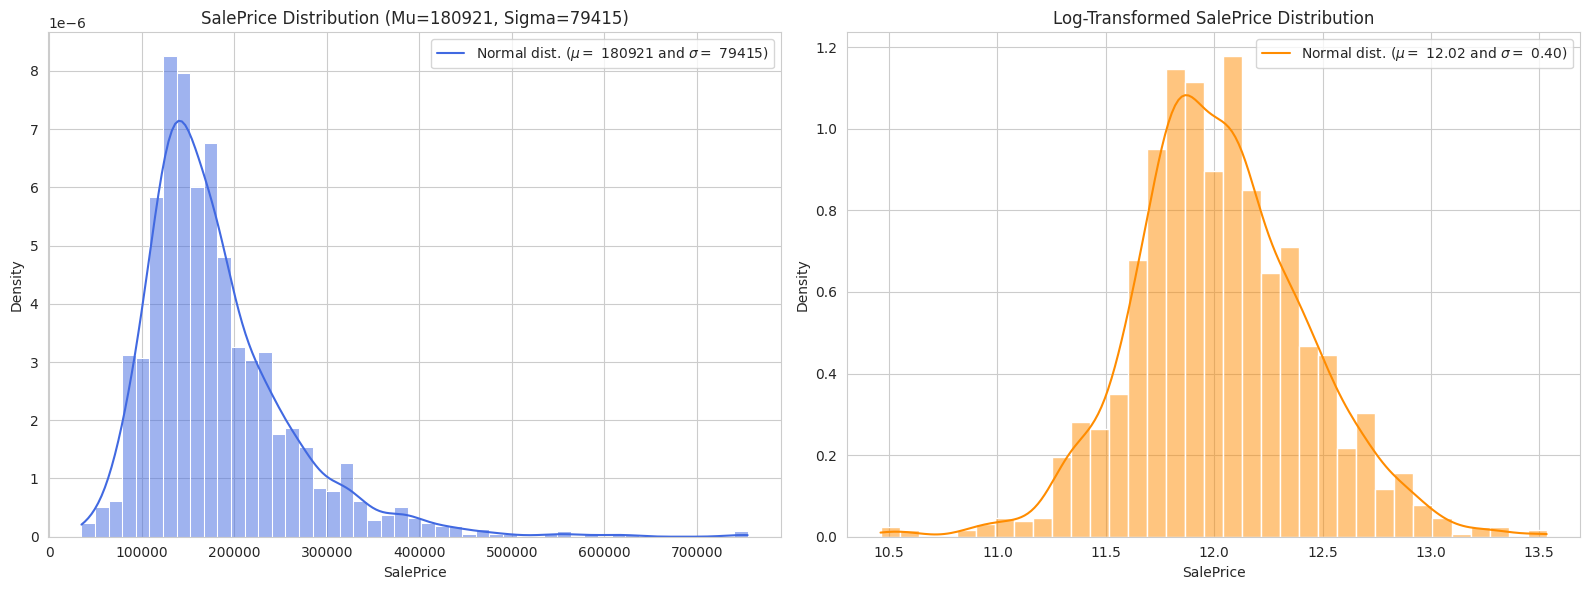

Skewness of raw SalePrice: 1.8829
Skewness of Log SalePrice: 0.1213


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of SalePrice
sns.histplot(train['SalePrice'], kde=True, stat='density', ax=ax[0], color='royalblue')
mu, sigma = norm.fit(train['SalePrice'])
ax[0].set_title(f'SalePrice Distribution (Mu={mu:.0f}, Sigma={sigma:.0f})')
ax[0].legend([f'Normal dist. ($\mu=$ {mu:.0f} and $\sigma=$ {sigma:.0f})'], loc='best')

# Log-transformed SalePrice
sns.histplot(np.log1p(train['SalePrice']), kde=True, stat='density', ax=ax[1], color='darkorange')
mu_log, sigma_log = norm.fit(np.log1p(train['SalePrice']))
ax[1].set_title('Log-Transformed SalePrice Distribution')
ax[1].legend([f'Normal dist. ($\mu=$ {mu_log:.2f} and $\sigma=$ {sigma_log:.2f})'], loc='best')

plt.tight_layout()
plt.show()

print(f"Skewness of raw SalePrice: {train['SalePrice'].skew():.4f}")
print(f"Skewness of Log SalePrice: {np.log1p(train['SalePrice']).skew():.4f}")

***Interpretation:*** Pricing Strategy & Market Positioning
The raw SalePrice is right-skewed (Skewness = 1.88). This tells that the market is dominated by mid-range homes, with a long tail of luxury/premium properties.

## 5. Numerical features: Identifying value drivers

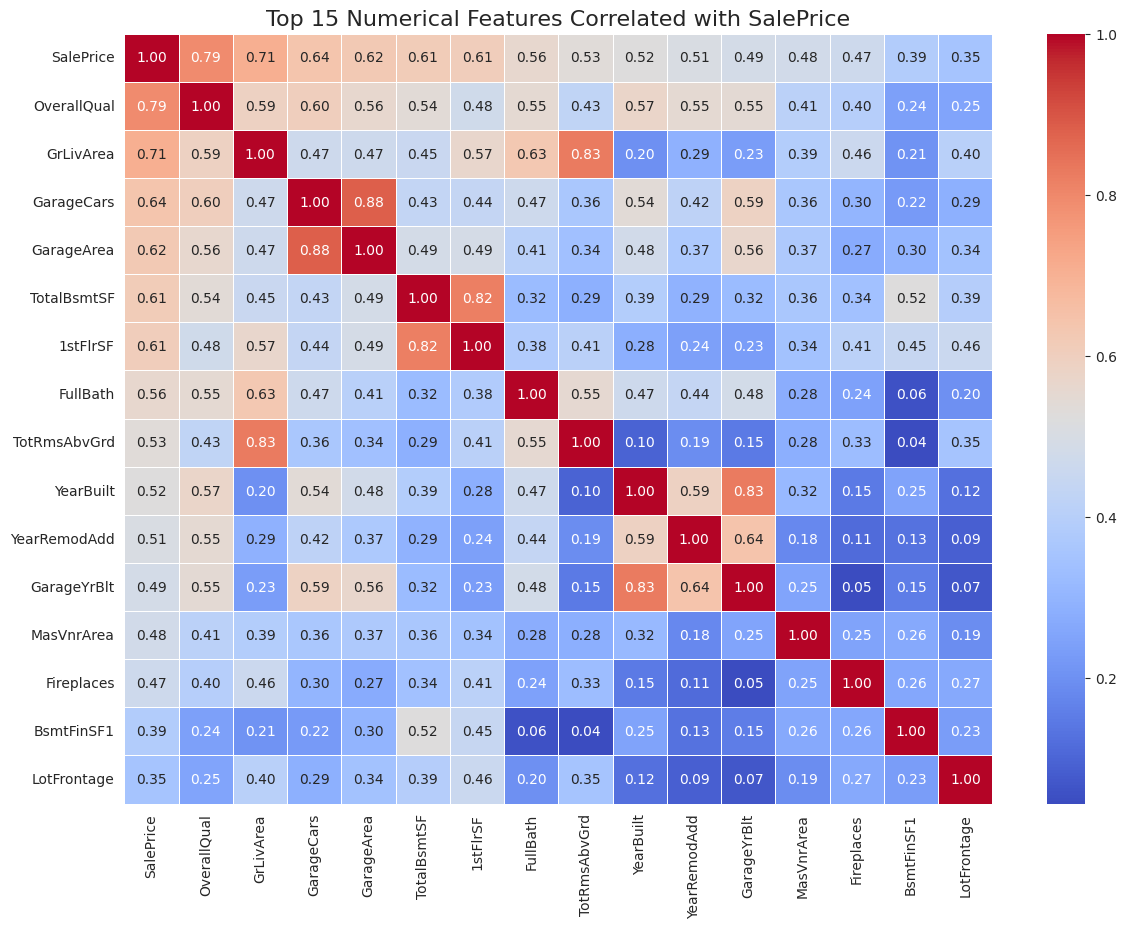

In [4]:
# Correlation Matrix
numeric_cols = train.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

# Top 15 features correlated with SalePrice
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(16).index
top_corr_matrix = train[top_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Top 15 Numerical Features Correlated with SalePrice', fontsize=16)
plt.show()

***Interpretation:*** This chart identifies the 15 numerical variables that have the strongest linear relationship with the sale price. Dark red indicates a strong positive correlation (when the variable increases, the price increases), while cooler colors (blue) indicate a weaker correlation.
- Overall Quality (`OverallQual`) and Living Area (`GrLivArea`): These are the reddest boxes (correlation greater than 0.7). This means that the quality of materials/finishes and the size of the living space above ground are the number one factors that determine a home's price.
- Garage (`GarageCars`, `GarageArea`): The garage's capacity (number of cars) and its size come next. A large garage adds significant value to the property.
- Basement (`TotalBsmtSF`) and First Floor (`1stFlrSF`): The total area of ​​the basement and first floor are also strong price indicators (0.61), showing that buyers value total usable space.
- The variables `YearBuilt` (year of construction) and `YearRemodAdd` (year of renovation) show a notable correlation, regarding the impact of modernity. This indicates that newer homes or those that have been recently renovated sell for a higher price on the market.

## 6. Key business features

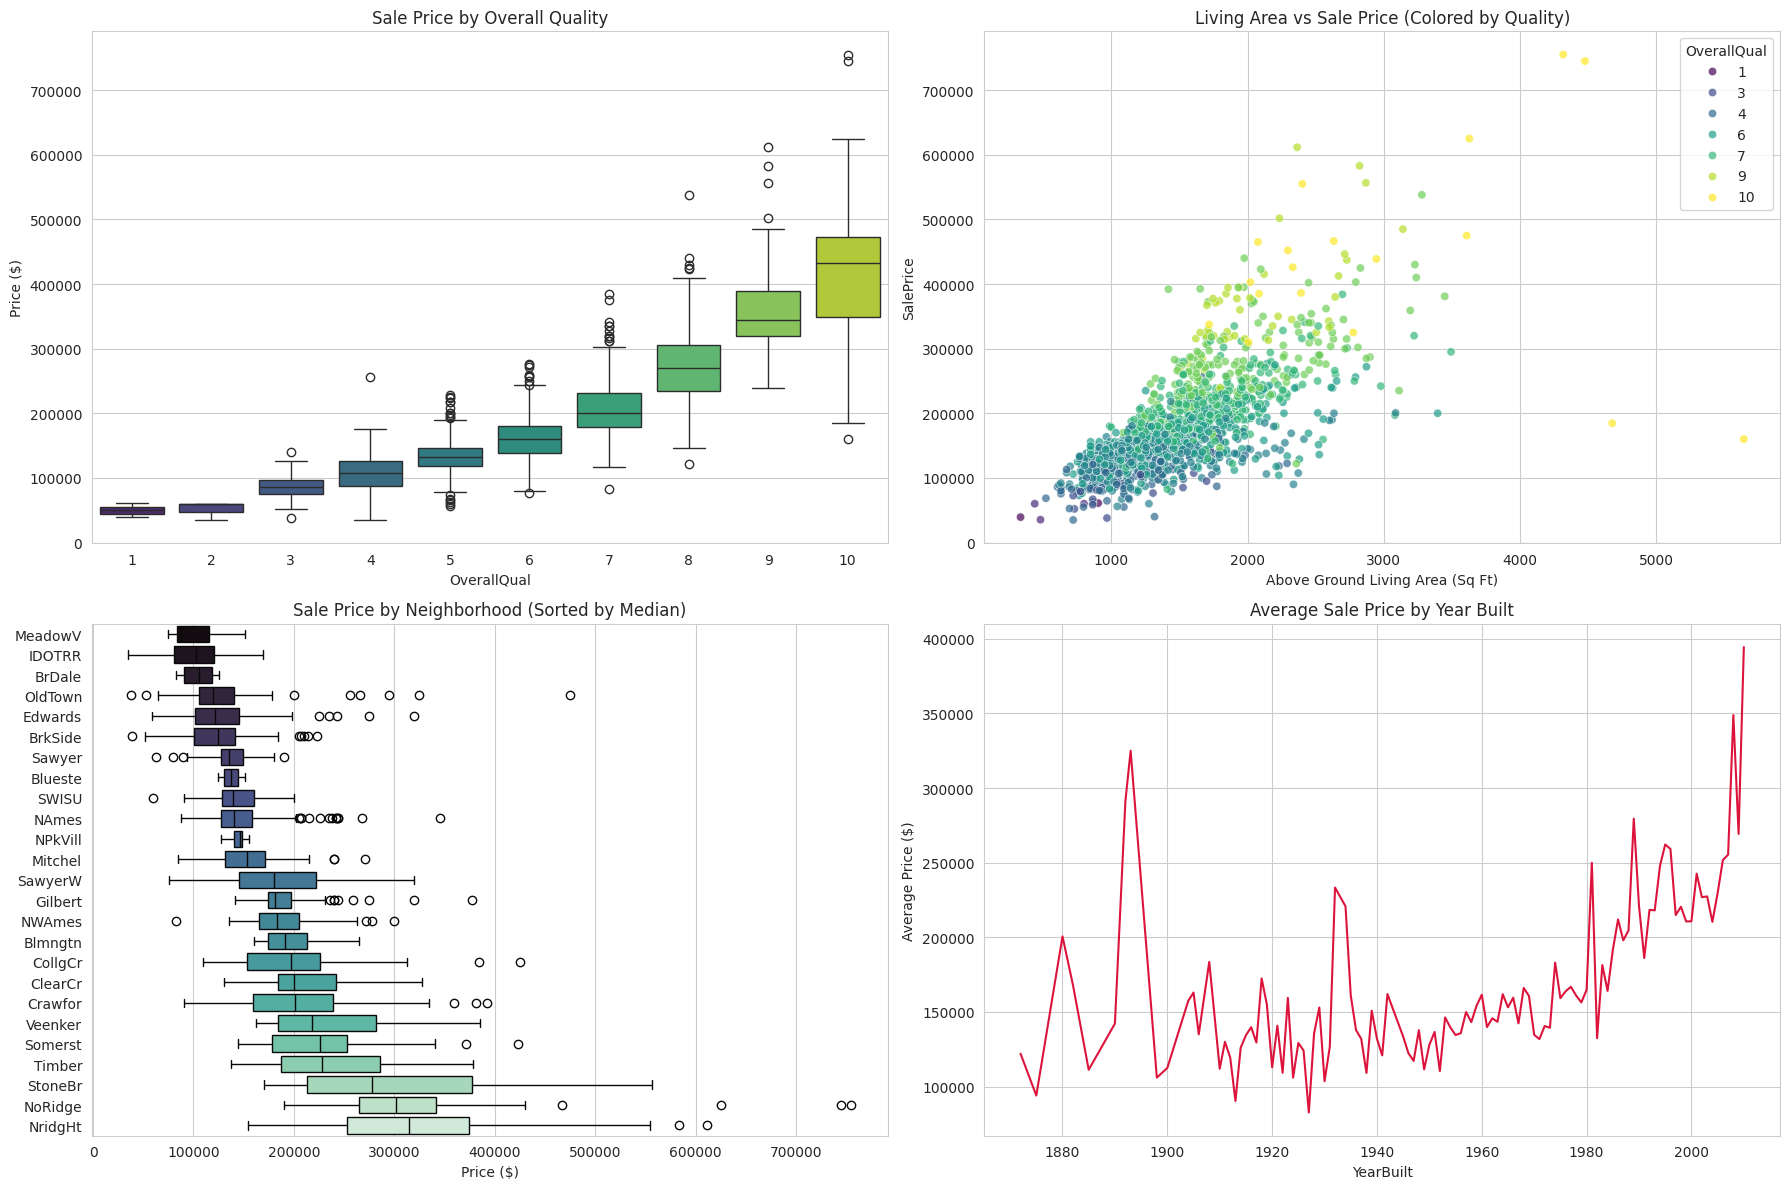

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# Overall Quality vs SalePrice
sns.boxplot(x='OverallQual', y='SalePrice', data=train, ax=ax[0,0], palette='viridis')
ax[0,0].set_title('Sale Price by Overall Quality')
ax[0,0].set_ylabel('Price ($)')

# Above Grade Living Area vs SalePrice
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, ax=ax[0,1], hue='OverallQual', palette='viridis', alpha=0.7)
ax[0,1].set_title('Living Area vs Sale Price (Colored by Quality)')
ax[0,1].set_xlabel('Above Ground Living Area (Sq Ft)')

# Neighborhood vs SalePrice (Sorted by median)
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(x='SalePrice', y='Neighborhood', data=train, ax=ax[1,0], order=order, palette='mako')
ax[1,0].set_title('Sale Price by Neighborhood (Sorted by Median)')
ax[1,0].set_xlabel('Price ($)')
ax[1,0].set_ylabel('')

# Year Built vs SalePrice
sns.lineplot(x='YearBuilt', y='SalePrice', data=train, ax=ax[1,1], color='crimson', ci=None)
ax[1,1].set_title('Average Sale Price by Year Built')
ax[1,1].set_ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

***Interpretation:***
- There is an exponential jump in price once `OverallQual` hits 8 (Very Good) or higher. Renovations that bump a home from a 6 to an 8 yield disproportionate ROI.
- The scatter plot shows that large homes (`GrLivArea` > 4000) with low quality (4-5) actually sell for less than smaller, high-quality homes. Buyers penalize "cheap flips" on large footprints.
- `NoRidge`, `NridgHt`, and `StoneBr` are the premium neighborhoods. `MeadowV`, `IDOTRR`, and `BrDale` are entry-level. A real estate agency should segment its agent teams by these tiers.
- Homes built between 1940 and 1980 have lower average prices, while homes built after 1981 command a massive premium.

## 7. Temporal market trends: When to buy and sell

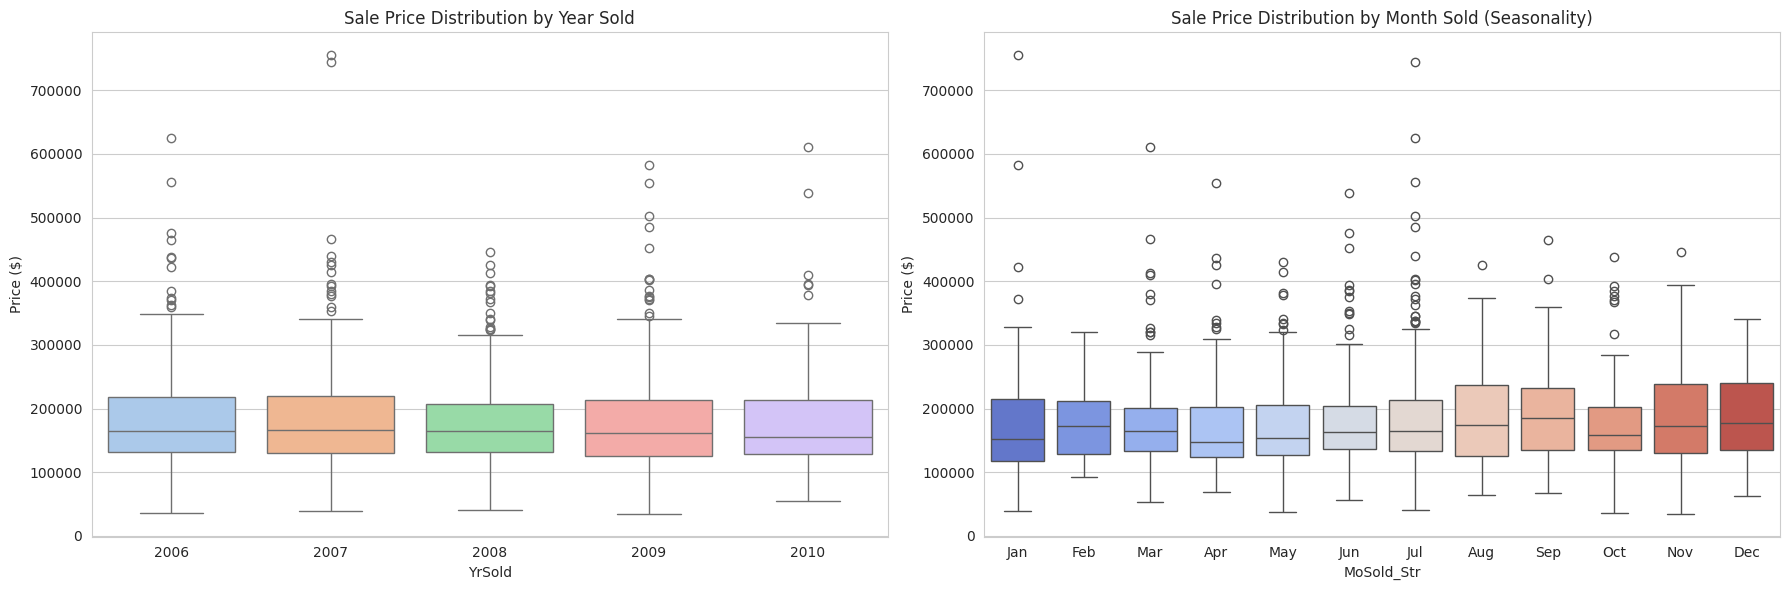

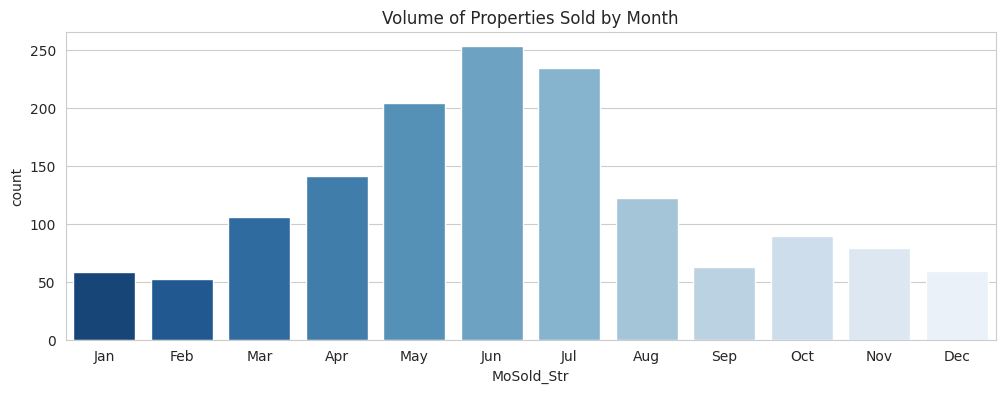

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Year Sold vs SalePrice (Accounting for inflation/market shifts)
sns.boxplot(x='YrSold', y='SalePrice', data=train, ax=ax[0], palette='pastel')
ax[0].set_title('Sale Price Distribution by Year Sold')
ax[0].set_ylabel('Price ($)')

# Month Sold vs SalePrice (Seasonality)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
train['MoSold_Str'] = train['MoSold'].apply(lambda x: month_order[x-1])
sns.boxplot(x='MoSold_Str', y='SalePrice', data=train, ax=ax[1], order=month_order, palette='coolwarm')
ax[1].set_title('Sale Price Distribution by Month Sold (Seasonality)')
ax[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

# Volume of sales by month
plt.figure(figsize=(12, 4))
sns.countplot(x='MoSold_Str', data=train, order=month_order, palette='Blues_r')
plt.title('Volume of Properties Sold by Month')
plt.show()

***Interpretation:***
- Market Stability: The boxplot for `YrSold` (2006-2010) shows relatively stable median prices, though 2009-2010 shows a slight dip at the lower quartiles, likely reflecting the aftermath of the 2008 housing crisis.
- Supply vs. Demand: The volume of sales peaks dramatically in May, June, and July.
- Pricing Seasonality: While volume is high in summer, prices do not dramatically spike. The best time to list a home for maximum exposure is Spring/early Summer. Conversely, buyers might find less competition (but also less inventory) in the winter months.

## 8. Categorical feature analysis

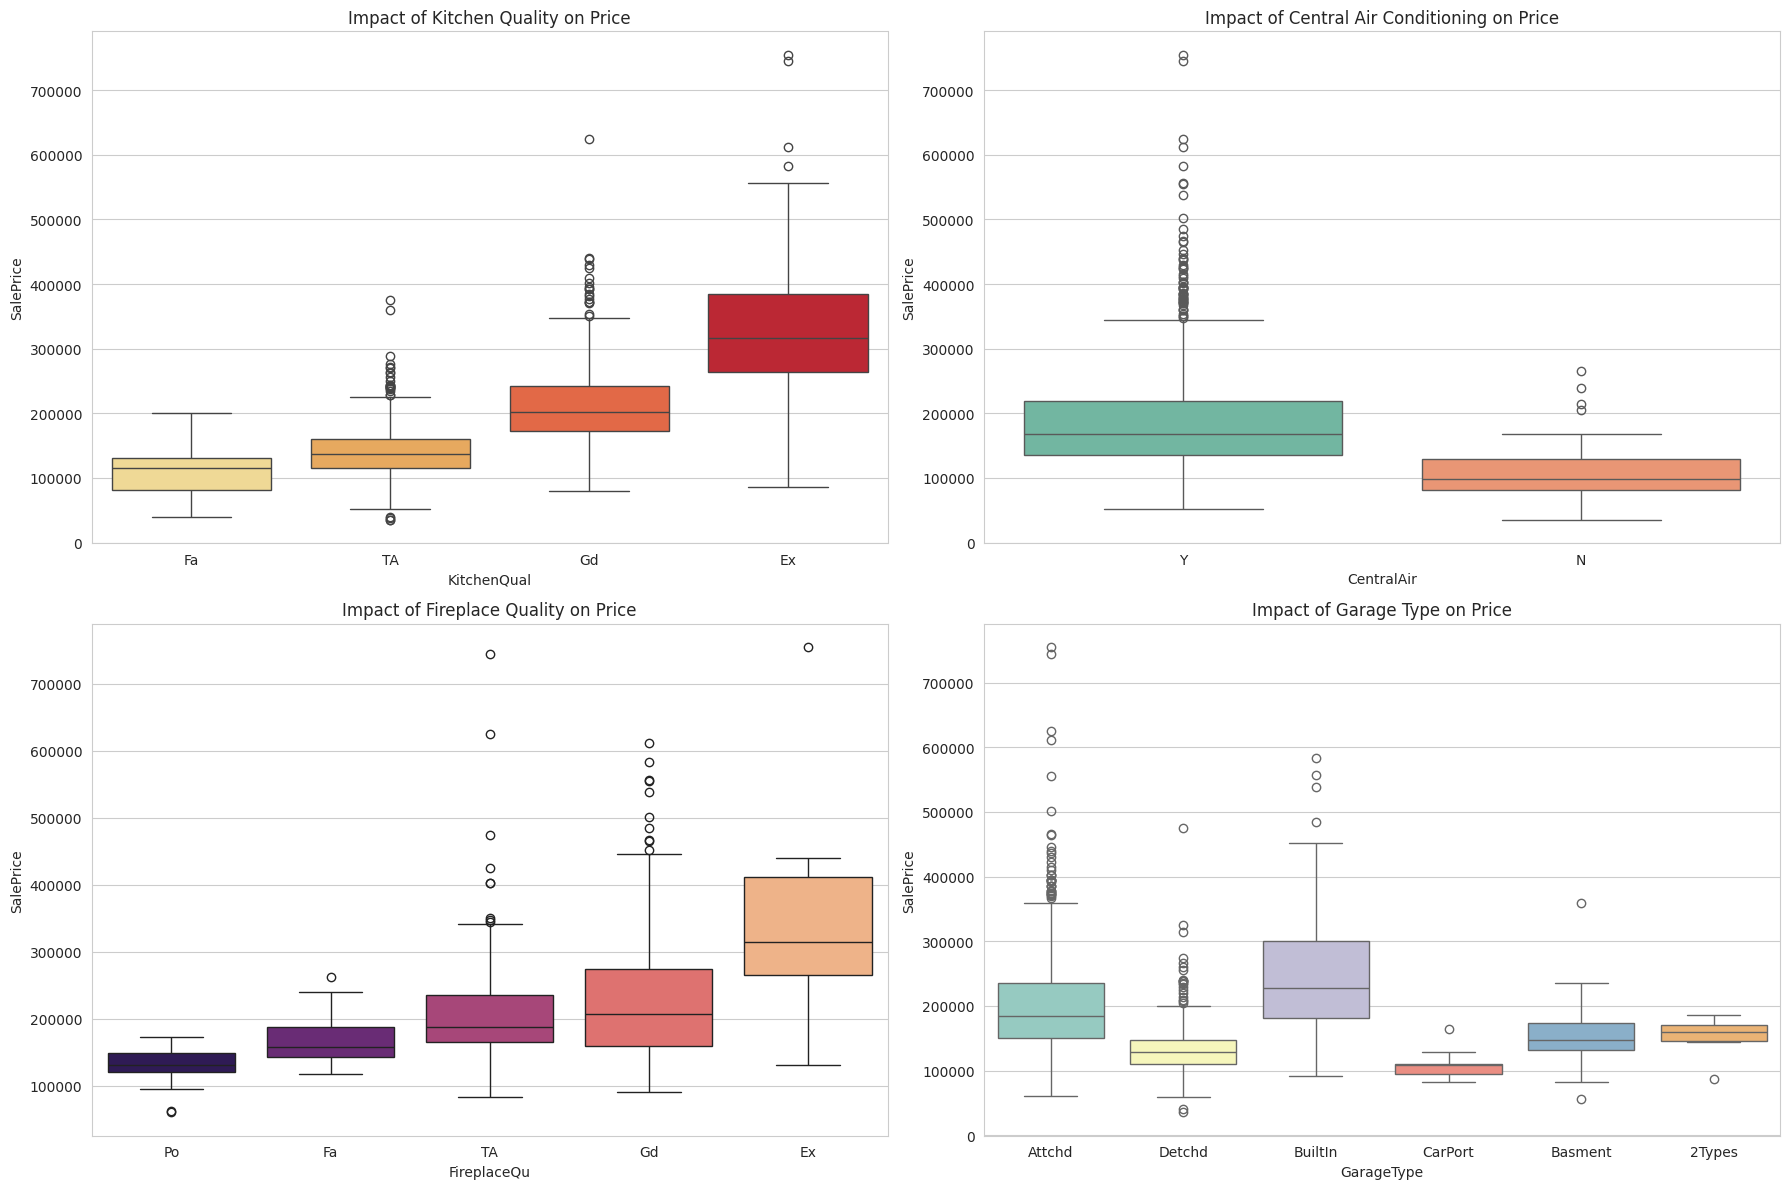

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# Kitchen Quality
sns.boxplot(x='KitchenQual', y='SalePrice', data=train, ax=ax[0,0], order=['Fa','TA','Gd','Ex'], palette='YlOrRd')
ax[0,0].set_title('Impact of Kitchen Quality on Price')

# Heating and Air Conditioning
sns.boxplot(x='CentralAir', y='SalePrice', data=train, ax=ax[0,1], palette='Set2')
ax[0,1].set_title('Impact of Central Air Conditioning on Price')

# Fireplace Quality
sns.boxplot(x='FireplaceQu', y='SalePrice', data=train, ax=ax[1,0], order=['Po','Fa','TA','Gd','Ex'], palette='magma')
ax[1,0].set_title('Impact of Fireplace Quality on Price')

# Garage Type
sns.boxplot(x='GarageType', y='SalePrice', data=train, ax=ax[1,1], palette='Set3')
ax[1,1].set_title('Impact of Garage Type on Price')

plt.tight_layout()
plt.show()

***Interpretation:***
- Kitchen is King: Upgrading a kitchen from `TA` (Typical) to `Gd` (Good) or `Ex` (Excellent) yields a massive increase in median home value. This is the highest ROI renovation for flippers.
- Climate Control: Central Air Conditioning (`CentralAir` = `Y`) is practically a requirement for modern buyers; homes without it suffer a significant price penalty.
- Fireplaces: An Excellent fireplace adds significant luxury value, acting as a focal point for premium buyers.
- Garage Type: `BuiltIn` and `Attchd` garages are standard and expected. `CarPort` significantly devalues a property compared to a full garage.

## 9. Machine Learning: Predicting house prices

The following pipeline is designed to employ advanced feature engineering, target transformation (Log1p), handling of missing values based on the data dictionary, skewness correction, and an ensemble modeling approach (Stacking with XGBoost, LightGBM, and Ridge).

### 9.1. Data preparation & Feature engineering

In [8]:
# Reload data to ensure clean state
train = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

# Save IDs and Target
train_ID = train['Id']
test_ID = test['Id']
train.drop('Id', axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

# Log-transform the target variable (SalePrice) to fix right-skewness
# This is crucial for RMSLE optimization
train["SalePrice"] = np.log1p(train["SalePrice"])
y = train.SalePrice.values

# Combine train and test for unified feature engineering
train.drop(['SalePrice'], axis=1, inplace=True)
all_data = pd.concat([train, test]).reset_index(drop=True)
print(f"Combined dataset shape: {all_data.shape}")

Combined dataset shape: (2919, 79)


### 9.2. Advanced missing value imputation

In [9]:
# Based on the data_description.txt, NA means "None" for these features
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

# Numerical features where NA means 0
zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)
    
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# Mode imputation for remaining categorical/numeric fields
mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Utilities', 'Functional']
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Drop features with severe leakage or single dominant value
all_data = all_data.drop(['Utilities', 'Street', 'PoolQC'], axis=1)

# Verify no missing values remain
print(f"Total missing values left: {all_data.isnull().sum().sum()}")

Total missing values left: 0


### 9.3. Feature engineering & Transformations

In [10]:
# Create new meaningful features
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['Total_Bathrooms'] = (all_data['FullBath'] + (0.5 * all_data['HalfBath']) +
                               all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath']))
all_data['Total_porch_sf'] = (all_data['OpenPorchSF'] + all_data['3SsnPorch'] +
                              all_data['EnclosedPorch'] + all_data['ScreenPorch'] +
                              all_data['WoodDeckSF'])

# Simplify some features
all_data['HasPool'] = all_data['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['Has2ndFloor'] = all_data['2ndFlrSF'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasGarage'] = all_data['GarageArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasBsmt'] = all_data['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasFireplace'] = all_data['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)

# Handle skewness in numerical features
numeric_feats = all_data.select_dtypes(include=[np.number]).columns

# Calculate skewness
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skew': skewed_feats})
skewness = skewness[abs(skewness) > 0.75]

# Apply Box-Cox transformation to skewed features
skewed_features = skewness.index
lam = 0.15
for feat in skewed_features:
    all_data[feat] = boxcox1p(all_data[feat], lam)

# Convert categorical variables to dummy variables (One-Hot Encoding)
all_data = pd.get_dummies(all_data)
print(f"Final dataset shape after encoding: {all_data.shape}")

# Split back into train and test sets
X_train = all_data[:len(train)]
X_test = all_data[len(train):]

Final dataset shape after encoding: (2919, 302)


### 9.4. Model definition & Cross validation

In [11]:
# Define a K-Fold cross-validation strategy
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Define RMSLE evaluation function
def rmsle_cv(model):
    kf = KFold(n_folds, shuffle=True, random_state=42).get_n_splits(X_train.values)
    rmse = np.sqrt(-cross_val_score(model, X_train.values, y, scoring="neg_mean_squared_error", cv=kf))
    return rmse

# Base Models
ridge = make_pipeline(RobustScaler(), Ridge(alpha=10.0, random_state=42))
lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=42, max_iter=10000))
elastic = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=42, max_iter=10000))

# Gradient Boosting Models
gbr = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05,
                                max_depth=4, max_features='sqrt',
                                min_samples_leaf=15, min_samples_split=10, 
                                loss='huber', random_state=42)

xgbr = xgb.XGBRegressor(learning_rate=0.05, n_estimators=2200,
                        max_depth=3, min_child_weight=0,
                        gamma=0, subsample=0.7,
                        colsample_bytree=0.7,
                        objective='reg:squarederror', nthread=-1,
                        scale_pos_weight=1, seed=42, eval_metric='rmse')

lgbr = lgb.LGBMRegressor(objective='regression', num_leaves=5,
                         learning_rate=0.05, n_estimators=720,
                         max_bin=55, bagging_fraction=0.8,
                         bagging_freq=5, feature_fraction=0.2319,
                         feature_fraction_seed=9, bagging_seed=9,
                         min_data_in_leaf=6, min_sum_hessian_in_leaf=11)

# Scoring the models
for model_name, model in [('Ridge', ridge), ('Lasso', lasso), ('ElasticNet', elastic), 
                          ('GBR', gbr), ('XGBoost', xgbr), ('LightGBM', lgbr)]:
    score = rmsle_cv(model)
    print(f"{model_name} score: {score.mean():.4f} ({score.std():.4f})")

Ridge score: 0.1281 (0.0155)
Lasso score: 0.1234 (0.0168)
ElasticNet score: 0.1236 (0.0168)
GBR score: 0.1231 (0.0129)
XGBoost score: 0.1205 (0.0104)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value

### 9.5. Stacking models

In [12]:
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone

class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, models):
        self.models = models
        
    def fit(self, X, y):
        self.models_ = [clone(x) for x in self.models]
        for model in self.models_:
            model.fit(X, y)
        return self
    
    def predict(self, X):
        predictions = np.column_stack([model.predict(X) for model in self.models_])
        return np.mean(predictions, axis=1)

# Average the top performing models
averaged_models = AveragingModels(models=(ridge, lasso, elastic, xgbr, lgbr, gbr))

score = rmsle_cv(averaged_models)
print(f"Averaged base models score: {score.mean():.4f} ({score.std():.4f})")

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319

### 9.6. Final training & Submission generation

In [13]:
# Train the final averaged ensemble on the full training dataset
averaged_models.fit(X_train.values, y)

# Predict on the test set
final_predictions = np.expm1(averaged_models.predict(X_test.values))

# Clip predictions to ensure no extreme outliers
final_predictions = np.clip(final_predictions, 0, None)

# Create the submission dataframe
submission = pd.DataFrame({
    'Id': test_ID,
    'SalePrice': final_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("submission.csv has been successfully generated!")
display(submission.head())

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319

,Id,SalePrice
0,1461,121553.123151
1,1462,158279.683255
2,1463,184194.655835
3,1464,195973.165143
4,1465,192568.949780


## Conclusion

Throughout this notebook, we journeyed from raw, uncleaned housing data to a robust predictive Machine Learning model. We discovered that variables such as overall quality (`OverallQual`), living area (`GrLivArea`), and garage size play a paramount role in determining a home's `SalePrice`. We successfully mapped variables with extremely high missing rates like `PoolQC` (99.6%), `MiscFeature` (96.4%), and `Alley` (93.2%), realizing that these were not truly missing data, but rather indicators of the absence of these rare amenities. And neighborhoods showed clear segmentations, with specific areas consistently commanding premium prices.

Among the models tested, our ensemble models (XGBoost and LightGBM in particular) and regularized linear models (Lasso/Ridge) performed well. Finally, using robust scaling and handling skewed features via Box-Cox transformations proved essential in stabilizing our linear models and improving overall accuracy.

While our current models perform very well, future improvements could include external data, for example by gathering macroeconomic data (e.g., historical interest rates) to capture broader market trends impacting the `SalePrice`.